In [11]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectPercentile, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [15]:
DATA_PATH = r"C:\Users\User\OneDrive - Faculty of Computers and Information Technology (Zagazig University)\Desktop\METABRIC_RNA_Mutation.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Number of rows: 1904
Number of columns: 693


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [17]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.value_counts().to_frame("Number of columns"))

print("\nDataset information:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (1904, 693)

Column names:
['patient_id', 'age_at_diagnosis', 'type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'chemotherapy', 'pam50_+_claudin-low_subtype', 'cohort', 'er_status_measured_by_ihc', 'er_status', 'neoplasm_histologic_grade', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'hormone_therapy', 'inferred_menopausal_state', 'integrative_cluster', 'primary_tumor_laterality', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'oncotree_code', 'overall_survival_months', 'overall_survival', 'pr_status', 'radio_therapy', '3-gene_classifier_subtype', 'tumor_size', 'tumor_stage', 'death_from_cancer', 'brca1', 'brca2', 'palb2', 'pten', 'tp53', 'atm', 'cdh1', 'chek2', 'nbn', 'nf1', 'stk11', 'bard1', 'mlh1', 'msh2', 'msh6', 'pms2', 'epcam', 'rad51c', 'rad51d', 'rad50', 'rb1', 'rbl1', 'rbl2', 'ccna1', 'ccnb1', 'cdk1', 'ccne1', 'cdk2', 'cdc25a', 'ccnd1', 'cdk4', 'cdk6', 'ccnd2', '

,Number of columns
float64,498
object,190
int64,5



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Columns: 693 entries, patient_id to siah1_mut
dtypes: float64(498), int64(5), object(190)
memory usage: 10.1+ MB

First 5 rows:


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [19]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df) * 100).round(2)
}).sort_values("Missing Percentage", ascending=False)

display(missing_summary.head(30))

print("Duplicated rows:", df.duplicated().sum())
print("Unique rows:", len(df.drop_duplicates()))

,Missing Values,Missing Percentage
tumor_stage,501,26.31
3-gene_classifier_subtype,204,10.71
primary_tumor_laterality,106,5.57
neoplasm_histologic_grade,72,3.78
cellularity,54,2.84
mutation_count,45,2.36
er_status_measured_by_ihc,30,1.58
type_of_breast_surgery,22,1.16
tumor_size,20,1.05
cancer_type_detailed,15,0.79


Duplicated rows: 0
Unique rows: 1904


In [21]:
df = df.drop_duplicates().copy()

empty_columns = df.columns[df.isna().all()].tolist()

print("Completely empty columns:", empty_columns)

if empty_columns:
    df = df.drop(columns=empty_columns)

print("Shape after basic cleaning:", df.shape)

Completely empty columns: []
Shape after basic cleaning: (1904, 693)


In [23]:
TARGET = "overall_survival"

if TARGET not in df.columns:
    raise ValueError(
        f"Target '{TARGET}' was not found. "
        "Check the column names printed in Step 5."
    )

print("Target distribution:")
display(df[TARGET].value_counts(dropna=False).to_frame("Count"))

print("\nTarget percentages:")
display(
    (df[TARGET].value_counts(normalize=True, dropna=False) * 100)
    .round(2)
    .to_frame("Percentage")
)

print("\nMissing target values:", df[TARGET].isna().sum())

Target distribution:


,Count
overall_survival,
0,1103
1,801



Target percentages:


,Percentage
overall_survival,
0,57.93
1,42.07



Missing target values: 0


In [31]:
df_model = df.dropna(subset=[TARGET]).copy()

columns_to_exclude = [
    TARGET,
    "patient_id",
    "overall_survival_months",
    "death_from_cancer"
]

columns_to_exclude = [
    col for col in columns_to_exclude
    if col in df_model.columns
]

X = df_model.drop(columns=columns_to_exclude).copy()
y = df_model[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget classes:")
print(y.value_counts())

print("\nNumber of input features:", X.shape[1])

X shape: (1904, 689)
y shape: (1904,)

Target classes:
overall_survival
0    1103
1     801
Name: count, dtype: int64

Number of input features: 689


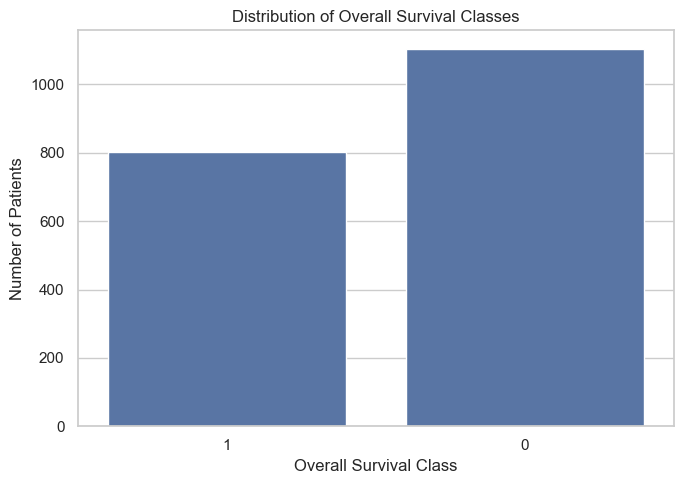

In [33]:
plt.figure(figsize=(7, 5))
sns.countplot(x=y.astype(str))
plt.title("Distribution of Overall Survival Classes")
plt.xlabel("Overall Survival Class")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

In [35]:
numeric_columns = X.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numeric columns:", len(numeric_columns))
print("Categorical columns:", len(categorical_columns))

print("\nNumeric examples:", numeric_columns[:15])
print("\nCategorical examples:", categorical_columns[:15])

Numeric columns: 500
Categorical columns: 189

Numeric examples: ['age_at_diagnosis', 'chemotherapy', 'cohort', 'neoplasm_histologic_grade', 'hormone_therapy', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'radio_therapy', 'tumor_size', 'tumor_stage', 'brca1', 'brca2', 'palb2', 'pten']

Categorical examples: ['type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'pam50_+_claudin-low_subtype', 'er_status_measured_by_ihc', 'er_status', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'inferred_menopausal_state', 'integrative_cluster', 'primary_tumor_laterality', 'oncotree_code', 'pr_status']


In [37]:
display(X[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
age_at_diagnosis,1904.0,6.108705e+01,12.978711,21.9300,51.375000,61.77000,70.592500,96.2900
chemotherapy,1904.0,2.079832e-01,0.405971,0.0000,0.000000,0.00000,0.000000,1.0000
cohort,1904.0,2.643908e+00,1.228615,1.0000,1.000000,3.00000,3.000000,5.0000
neoplasm_histologic_grade,1832.0,2.415939e+00,0.650612,1.0000,2.000000,3.00000,3.000000,3.0000
hormone_therapy,1904.0,6.165966e-01,0.486343,0.0000,0.000000,1.00000,1.000000,1.0000
...,...,...,...,...,...,...,...,...
tnk2,1904.0,3.676471e-07,1.000264,-3.8333,-0.666475,0.00070,0.642900,3.9388
tulp4,1904.0,4.726891e-07,1.000262,-3.6093,-0.710200,-0.02980,0.595725,3.8334
ugt2b15,1904.0,7.878151e-07,1.000263,-1.1669,-0.505825,-0.28855,0.060225,10.8849
ugt2b17,1904.0,0.000000e+00,1.000262,-2.1126,-0.476200,-0.13340,0.270375,12.6439


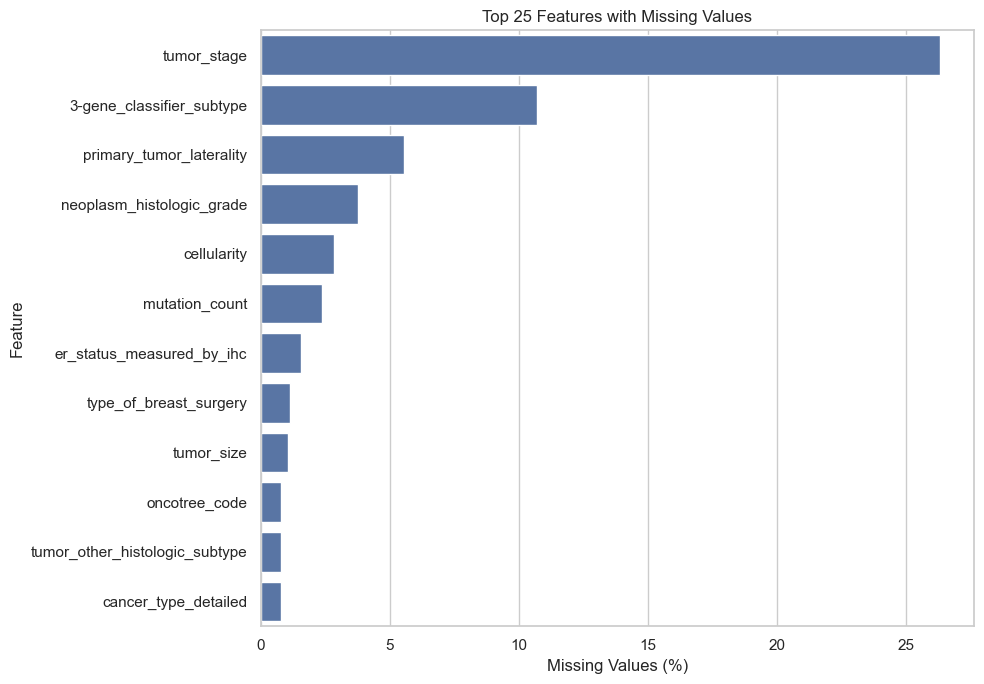

In [39]:
missing_percent = (X.isnull().mean() * 100).sort_values(
    ascending=False
)

missing_percent = missing_percent[missing_percent > 0].head(25)

if len(missing_percent) > 0:
    plt.figure(figsize=(10, 7))
    sns.barplot(
        x=missing_percent.values,
        y=missing_percent.index
    )
    plt.title("Top 25 Features with Missing Values")
    plt.xlabel("Missing Values (%)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in X.")

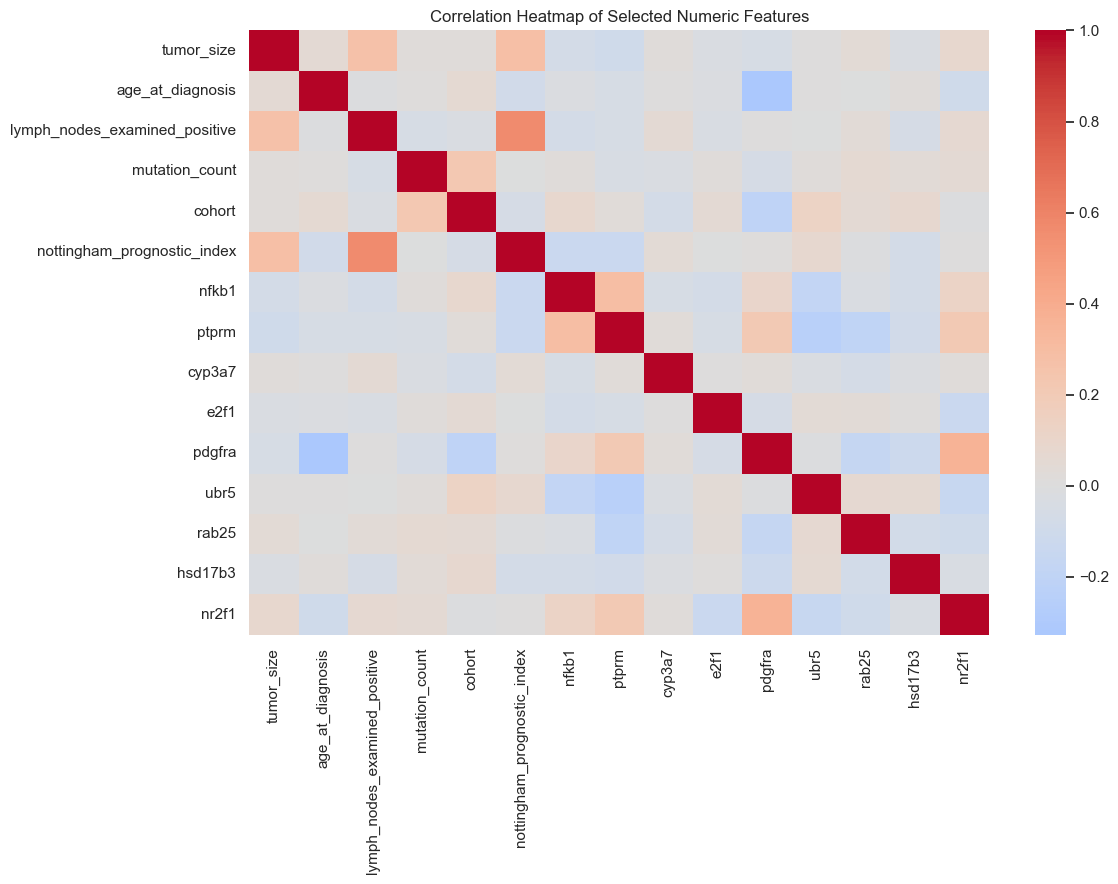

In [41]:
if len(numeric_columns) >= 2:
    top_variance_columns = (
        X[numeric_columns]
        .var()
        .sort_values(ascending=False)
        .head(15)
        .index
    )

    correlation_matrix = X[top_variance_columns].corr()

    plt.figure(figsize=(12, 9))
    sns.heatmap(
        correlation_matrix,
        cmap="coolwarm",
        center=0
    )
    plt.title("Correlation Heatmap of Selected Numeric Features")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric features for a correlation heatmap.")

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).round(3))

Training set: (1523, 689)
Testing set: (381, 689)

Training target distribution:


overall_survival
0    0.579
1    0.421
Name: proportion, dtype: float64


Testing target distribution:


overall_survival
0    0.58
1    0.42
Name: proportion, dtype: float64

In [45]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Preprocessor created successfully.")

Numeric features: 500
Categorical features: 189
Preprocessor created successfully.


In [47]:

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "SVC": SVC(
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

print("Models created:", list(models.keys()))

Models created: ['Logistic Regression', 'SVC', 'Random Forest', 'Extra Trees']


In [49]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1_weighted",
            "roc_auc": "roc_auc"
        },
        n_jobs=-1,
        error_score="raise"
    )

    cv_results.append({
        "Model": model_name,
        "Mean Accuracy": scores["test_accuracy"].mean(),
        "Mean F1": scores["test_f1"].mean(),
        "Mean ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    "Mean ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(cv_results_df)

,Model,Mean Accuracy,Mean F1,Mean ROC-AUC
0,SVC,0.697310,0.696450,0.751194
1,Extra Trees,0.671038,0.647997,0.731353
2,Random Forest,0.653971,0.625153,0.703615
3,Logistic Regression,0.654614,0.654555,0.698462


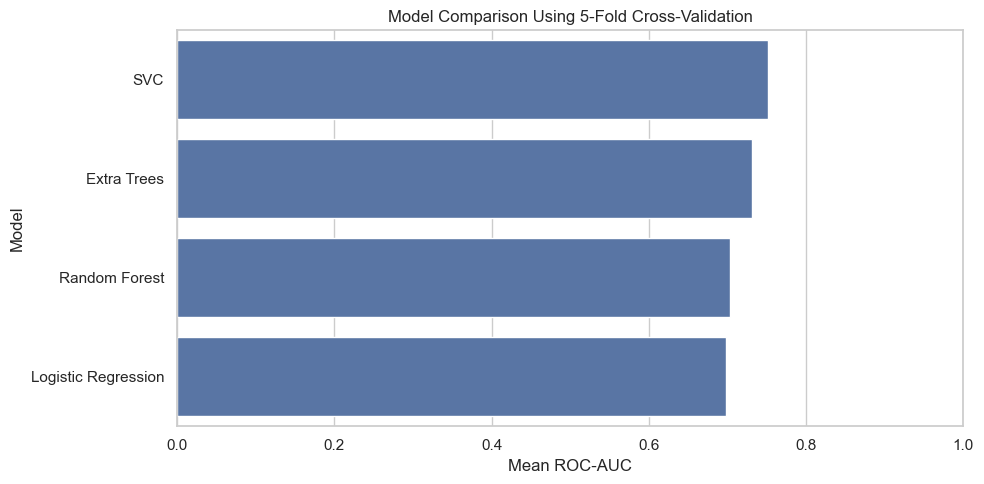

In [50]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=cv_results_df,
    x="Mean ROC-AUC",
    y="Model"
)

plt.title("Model Comparison Using 5-Fold Cross-Validation")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [53]:
param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.1, 1, 10]
    },
    "SVC": {
        "classifier__C": [0.1, 1, 10],
        "classifier__kernel": ["linear", "rbf"]
    },
    "Random Forest": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [None, 15],
        "classifier__min_samples_split": [2, 5]
    },
    "Extra Trees": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [None, 15],
        "classifier__min_samples_split": [2, 5]
    }
}

grid_searches = {}
tuning_results = []

for model_name, model in models.items():
    print("Tuning:", model_name)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    grid_searches[model_name] = grid_search

    tuning_results.append({
        "Model": model_name,
        "Best CV ROC-AUC": grid_search.best_score_,
        "Best Parameters": grid_search.best_params_
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    "Best CV ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(tuning_results_df)

Tuning: Logistic Regression
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Tuning: SVC
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Tuning: Random Forest
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Tuning: Extra Trees
Fitting 5 folds for each of 8 candidates, totalling 40 fits


,Model,Best CV ROC-AUC,Best Parameters
0,SVC,0.751194,"{'classifier__C': 1, 'classifier__kernel': 'rbf'}"
1,Extra Trees,0.732914,"{'classifier__max_depth': 15, 'classifier__min..."
2,Random Forest,0.718002,"{'classifier__max_depth': None, 'classifier__m..."
3,Logistic Regression,0.717451,{'classifier__C': 0.1}


In [54]:
best_model_name = max(
    grid_searches,
    key=lambda name: grid_searches[name].best_score_
)

best_grid = grid_searches[best_model_name]
best_model = best_grid.best_estimator_

print("Best model:", best_model_name)
print("Best CV ROC-AUC:", round(best_grid.best_score_, 4))
print("Best parameters:")
print(best_grid.best_params_)

Best model: SVC
Best CV ROC-AUC: 0.7512
Best parameters:
{'classifier__C': 1, 'classifier__kernel': 'rbf'}


In [55]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(
    y_test, y_pred, average="weighted", zero_division=0
)
test_recall = recall_score(
    y_test, y_pred, average="weighted", zero_division=0
)
test_f1 = f1_score(
    y_test, y_pred, average="weighted", zero_division=0
)
test_roc_auc = roc_auc_score(y_test, y_proba)

print("Best model:", best_model_name)
print("Test Accuracy:", round(test_accuracy, 4))
print("Test Precision (weighted):", round(test_precision, 4))
print("Test Recall (weighted):", round(test_recall, 4))
print("Test F1 (weighted):", round(test_f1, 4))
print("Test ROC-AUC:", round(test_roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Best model: SVC
Test Accuracy: 0.6667
Test Precision (weighted): 0.6664
Test Recall (weighted): 0.6667
Test F1 (weighted): 0.6665
Test ROC-AUC: 0.7163

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71       221
           1       0.60      0.60      0.60       160

    accuracy                           0.67       381
   macro avg       0.66      0.66      0.66       381
weighted avg       0.67      0.67      0.67       381



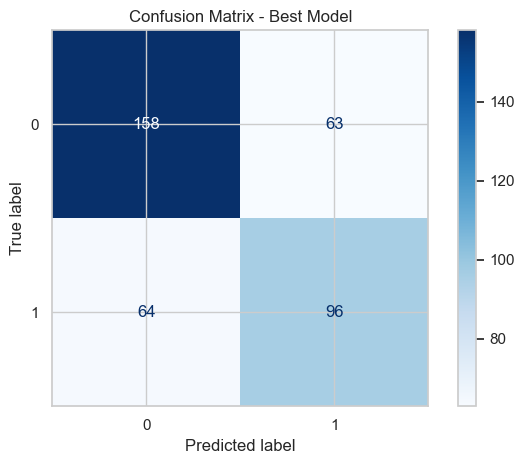

In [56]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Best Model")
plt.tight_layout()
plt.show()

In [57]:
X_train_processed = best_model.named_steps[
    "preprocessor"
].transform(X_train)

X_test_processed = best_model.named_steps[
    "preprocessor"
].transform(X_test)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (1523, 7128)
Processed testing shape: (381, 7128)


In [63]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_processed)

print("PCA shape:", X_train_pca.shape)
print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)
print(
    "Total variance explained:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

PCA shape: (1523, 2)
Explained variance ratio: [0.07568683 0.06757475]
Total variance explained: 0.1433


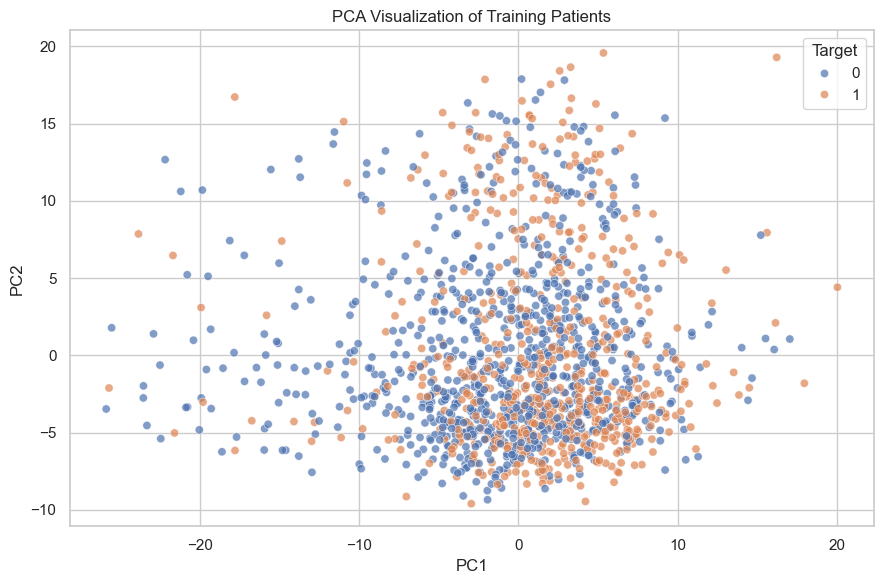

In [65]:
pca_df = pd.DataFrame({
    "PC1": X_train_pca[:, 0],
    "PC2": X_train_pca[:, 1],
    "Target": y_train.astype(str).to_numpy()
})

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Target",
    alpha=0.7
)

plt.title("PCA Visualization of Training Patients")
plt.tight_layout()
plt.show()

In [67]:
cluster_scores = []
kmeans_models = {}

max_k = min(6, len(X_train) - 1)

for k in range(2, max_k + 1):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_train_processed)

    score = silhouette_score(
        X_train_processed,
        cluster_labels,
        sample_size=min(1000, len(X_train_processed)),
        random_state=RANDOM_STATE
    )

    cluster_scores.append({
        "Number of Clusters": k,
        "Silhouette Score": score
    })

    kmeans_models[k] = kmeans

cluster_scores_df = pd.DataFrame(cluster_scores).sort_values(
    "Silhouette Score",
    ascending=False
).reset_index(drop=True)

display(cluster_scores_df)

,Number of Clusters,Silhouette Score
0,2,0.090741
1,3,0.084790
2,4,0.031955
3,6,0.024934
4,5,0.024168


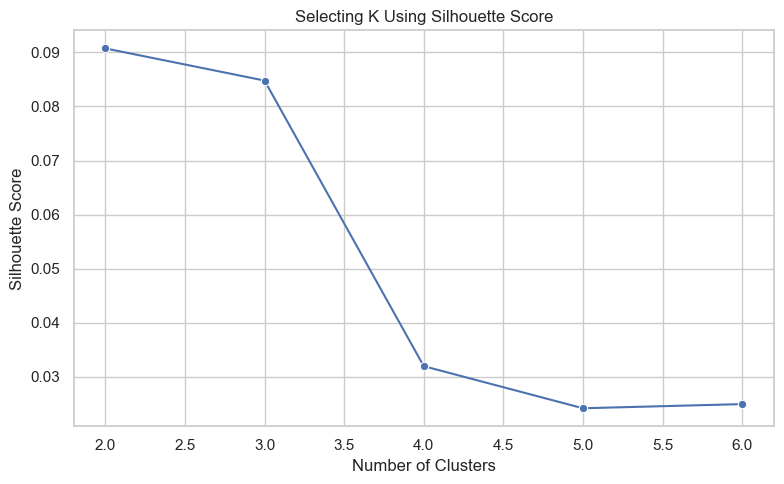

In [69]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=cluster_scores_df,
    x="Number of Clusters",
    y="Silhouette Score",
    marker="o"
)

plt.title("Selecting K Using Silhouette Score")
plt.tight_layout()
plt.show()

In [71]:
best_k = int(
    cluster_scores_df.iloc[0]["Number of Clusters"]
)

best_kmeans = kmeans_models[best_k]

train_clusters = best_kmeans.labels_

print("Selected number of clusters:", best_k)

print("\nCluster sizes:")
print(pd.Series(train_clusters).value_counts().sort_index())

Selected number of clusters: 2

Cluster sizes:
0     380
1    1143
Name: count, dtype: int64


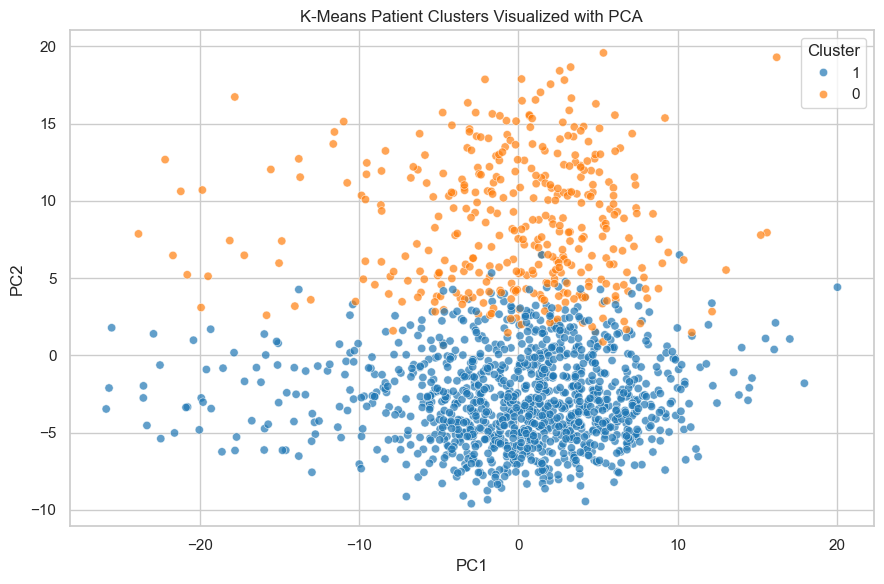

In [73]:
cluster_plot_df = pd.DataFrame({
    "PC1": X_train_pca[:, 0],
    "PC2": X_train_pca[:, 1],
    "Cluster": train_clusters.astype(str)
})

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=cluster_plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.7
)

plt.title("K-Means Patient Clusters Visualized with PCA")
plt.tight_layout()
plt.show()

In [75]:
cluster_analysis = pd.DataFrame({
    "Cluster": train_clusters,
    "Target": y_train.to_numpy()
})

cluster_target_table = pd.crosstab(
    cluster_analysis["Cluster"],
    cluster_analysis["Target"],
    normalize="index"
).round(3)

print("Target proportions inside each cluster:")
display(cluster_target_table)

print(
    "Note: This table describes associations; "
    "it does not establish clinical significance."
)

Target proportions inside each cluster:


Target,0,1
Cluster,,
0,0.566,0.434
1,0.584,0.416


Note: This table describes associations; it does not establish clinical significance.


In [77]:
OUTPUT_DIR = os.path.abspath("metabric_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output folder:", OUTPUT_DIR)

Output folder: C:\Users\User\metabric_outputs


In [79]:
model_path = os.path.join(
    OUTPUT_DIR,
    "metabric_best_model.joblib"
)

joblib.dump(best_model, model_path)

print("Model saved to:")
print(model_path)

Model saved to:
C:\Users\User\metabric_outputs\metabric_best_model.joblib


In [81]:
joblib.dump(
    pca,
    os.path.join(OUTPUT_DIR, "metabric_pca.joblib")
)

joblib.dump(
    best_kmeans,
    os.path.join(OUTPUT_DIR, "metabric_kmeans.joblib")
)

print("PCA and K-Means models saved successfully.")

PCA and K-Means models saved successfully.


In [83]:
metadata = {
    "target": TARGET,
    "excluded_columns": columns_to_exclude,
    "best_model_name": best_model_name,
    "best_parameters": best_grid.best_params_,
    "best_cv_roc_auc": float(best_grid.best_score_),
    "test_accuracy": float(test_accuracy),
    "test_precision_weighted": float(test_precision),
    "test_recall_weighted": float(test_recall),
    "test_f1_weighted": float(test_f1),
    "test_roc_auc": float(test_roc_auc),
    "random_state": RANDOM_STATE,
    "feature_columns": X.columns.tolist(),
    "target_classes": y.unique().tolist()
}

joblib.dump(
    metadata,
    os.path.join(OUTPUT_DIR, "metabric_metadata.joblib")
)

cv_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "cross_validation_results.csv"),
    index=False
)

tuning_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "hyperparameter_tuning_results.csv"),
    index=False
)

cluster_scores_df.to_csv(
    os.path.join(OUTPUT_DIR, "clustering_scores.csv"),
    index=False
)

print("Metadata and results saved successfully.")

Metadata and results saved successfully.


In [85]:
loaded_model = joblib.load(
    os.path.join(OUTPUT_DIR, "metabric_best_model.joblib")
)

sample_patient = X_test.iloc[[0]]

sample_prediction = loaded_model.predict(sample_patient)

print("Predicted class:", sample_prediction[0])

if hasattr(loaded_model, "predict_proba"):
    sample_probability = loaded_model.predict_proba(
        sample_patient
    )[0]

    print("Class probabilities:")

    for class_label, probability in zip(
        loaded_model.classes_,
        sample_probability
    ):
        print(f"Class {class_label}: {probability:.4f}")

Predicted class: 0
Class probabilities:
Class 0: 0.7963
Class 1: 0.2037
